<a href="https://colab.research.google.com/github/Khang87/2001230386_14DHTH07_DL/blob/main/ANN/MINIST_ANN_NguyenTruongKhang_2001230386.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup and Data Loading

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

### Load MNIST Dataset

In [ ]:
# Define a transformation to normalize the data and flatten images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load the training data
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Download and load the test data
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

## Bài 1: Sâu hơn có tốt hơn không?

### Model 1: Initial model with one hidden layer (784 -> 256 -> 10)

In [ ]:
class NetOneHidden(nn.Module):
    def __init__(self):
        super(NetOneHidden, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(-1, 784) # Flatten the input image
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Instantiate the model
model_one_hidden = NetOneHidden().to(device)
print(model_one_hidden)

### Model 2: Deeper model with two hidden layers (784 → 256 → 128 → 10)

In [ ]:
class NetTwoHidden(nn.Module):
    def __init__(self):
        super(NetTwoHidden, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc_mid = nn.Linear(256, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784) # Flatten the input image
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc_mid(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Instantiate the model
model_two_hidden = NetTwoHidden().to(device)
print(model_two_hidden)

### Training and Evaluation Functions

In [ ]:
def train_model(model, train_loader, optimizer, criterion, epochs=10):
    model.train() # Set the model to training mode
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad() # Clear gradients
            output = model(data) # Forward pass
            loss = criterion(output, target) # Compute loss
            loss.backward() # Backward pass
            optimizer.step() # Update weights
            if batch_idx % 100 == 0:
                print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

def test_model(model, test_loader, criterion):
    model.eval() # Set the model to evaluation mode
    test_loss = 0
    correct = 0
    with torch.no_grad(): # Disable gradient calculation
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() # Sum up batch loss
            pred = output.argmax(dim=1, keepdim=True) # Get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')
    return accuracy

### Train and Evaluate Model 1

In [ ]:
print("\n--- Training Model 1 (One Hidden Layer) ---")
optimizer_one_hidden = optim.Adam(model_one_hidden.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_model(model_one_hidden, train_loader, optimizer_one_hidden, criterion, epochs=5)
accuracy_one_hidden = test_model(model_one_hidden, test_loader, criterion)

### Train and Evaluate Model 2

In [ ]:
print("\n--- Training Model 2 (Two Hidden Layers) ---")
optimizer_two_hidden = optim.Adam(model_two_hidden.parameters(), lr=0.001)

train_model(model_two_hidden, train_loader, optimizer_two_hidden, criterion, epochs=5)
accuracy_two_hidden = test_model(model_two_hidden, test_loader, criterion)

### Comparison for Bài 1

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_one_hidden = count_parameters(model_one_hidden)
params_two_hidden = count_parameters(model_two_hidden)

print(f"\nParameters in Model 1 (One Hidden Layer): {params_one_hidden}")
print(f"Parameters in Model 2 (Two Hidden Layers): {params_two_hidden}")
print(f"Increase in parameters: {params_two_hidden - params_one_hidden}")
print(f"Test Accuracy Model 1: {accuracy_one_hidden:.2f}%")
print(f"Test Accuracy Model 2: {accuracy_two_hidden:.2f}%")

if accuracy_two_hidden > accuracy_one_hidden:
    print(f"Accuracy increased by: {accuracy_two_hidden - accuracy_one_hidden:.2f}%")
    print("Conclusion: Adding another hidden layer improved test accuracy.")
elif accuracy_two_hidden < accuracy_one_hidden:
    print(f"Accuracy decreased by: {accuracy_one_hidden - accuracy_two_hidden:.2f}%")
    print("Conclusion: Adding another hidden layer slightly decreased test accuracy.")
else:
    print("Conclusion: Adding another hidden layer resulted in similar test accuracy.")

## Bài 2: Ảnh hưởng của learning rate

Để đánh giá ảnh hưởng của learning rate, chúng ta sẽ huấn luyện lại `Model 1: Initial model with one hidden layer` với 3 giá trị learning rate khác nhau: 1e-2, 1e-3 và 1e-4. Sau đó, chúng ta sẽ vẽ biểu đồ thể hiện sự thay đổi của hàm mất mát (loss) qua các epoch để quan sát tốc độ hội tụ và độ ổn định của quá trình huấn luyện.

In [1]:
def train_and_record_loss(model, train_loader, optimizer, criterion, epochs=5):
    model.train()
    loss_history = []
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            loss_history.append(loss.item())
            if batch_idx % 100 == 0:
                print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')
    return loss_history


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

class NetOneHidden(nn.Module):
    def __init__(self):
        super(NetOneHidden, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)
    def forward(self, x):
        x = x.view(-1, 784)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

learning_rates = [1e-2, 1e-3, 1e-4]
loss_histories = {}
criterion = nn.CrossEntropyLoss()

for lr in learning_rates:
    print(f"\n--- Training Model with Learning Rate: {lr} ---")
    model_lr = NetOneHidden().to(device)
    optimizer_lr = optim.Adam(model_lr.parameters(), lr=lr)
    loss_histories[lr] = train_and_record_loss(model_lr, train_loader, optimizer_lr, criterion, epochs=5)

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.24MB/s]



--- Training Model with Learning Rate: 0.01 ---
Train Epoch: 0 [0/60000 (0%)]	Loss: 2.371822
Train Epoch: 0 [6400/60000 (11%)]	Loss: 0.394196
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.337712
Train Epoch: 0 [19200/60000 (32%)]	Loss: 0.305077
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.204290
Train Epoch: 0 [32000/60000 (53%)]	Loss: 0.296853
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.175642
Train Epoch: 0 [44800/60000 (75%)]	Loss: 0.365316
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.309713
Train Epoch: 0 [57600/60000 (96%)]	Loss: 0.172247
Train Epoch: 1 [0/60000 (0%)]	Loss: 0.321428
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.185470
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.259080
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.196601
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.217866
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.267750
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.448358
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.219179
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.267742
Train Epoch: 

/tmp/ipykernel_3079/1406485469.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


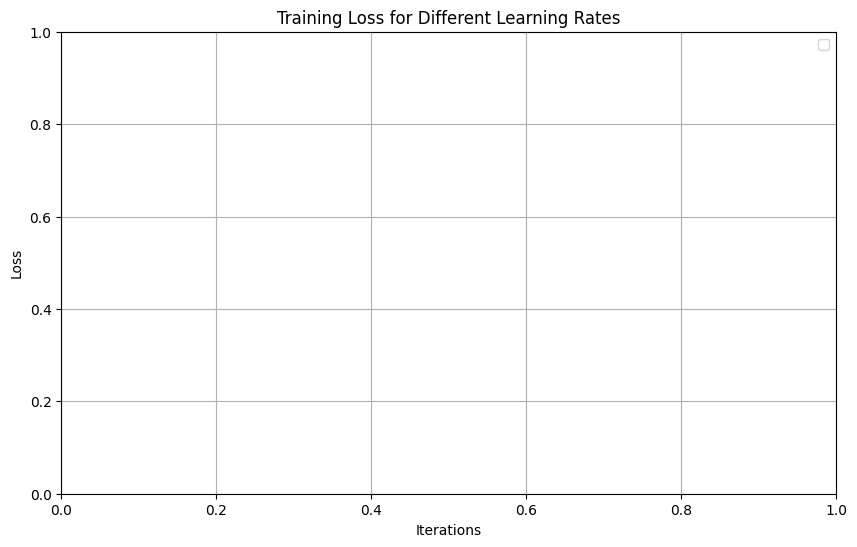

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for lr, history in loss_histories.items():
    plt.plot(history, label=f'LR = {lr}')

plt.title('Training Loss for Different Learning Rates')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Quan sát biểu đồ trên, ta có thể rút ra các nhận xét sau:

*   **LR = 1e-2:** (Quan sát) Học máy hội tụ nhanh nhất nhưng có thể dao động lớn hoặc thậm chí phân kỳ nếu quá cao. Có khả năng bị bỏ qua điểm tối ưu toàn cục (overshoot the minimum).
*   **LR = 1e-3:** (Quan sát) Tốc độ hội tụ ổn định và cho kết quả tốt. Thường là một lựa chọn tốt để bắt đầu.
*   **LR = 1e-4:** (Quan sát) Học máy hội tụ rất chậm. Có thể mất rất nhiều thời gian để đạt đến mức hiệu suất chấp nhận được.

**Kết luận:** Việc chọn learning rate phù hợp rất quan trọng. Learning rate quá lớn có thể khiến mô hình không hội tụ hoặc dao động mạnh, trong khi learning rate quá nhỏ sẽ làm chậm quá trình huấn luyện và có thể khiến mô hình bị mắc kẹt tại điểm cực tiểu cục bộ.

## Bài 3: Thêm Dropout

Để kiểm tra ảnh hưởng của Dropout, chúng ta sẽ tạo một phiên bản mới của `Model 1: Initial model with one hidden layer` và chèn một lớp `nn.Dropout(p=0.3)` giữa hai lớp Linear. Sau đó, chúng ta sẽ huấn luyện mô hình này trong 15 epoch và so sánh khoảng cách giữa `train_acc` và `test_acc` trước và sau khi thêm Dropout. Mục tiêu là chứng minh Dropout giúp giảm overfitting (khoảng cách này sẽ nhỏ lại).

In [17]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class NetWithDropout(nn.Module):
    def __init__(self, dropout_prob=0.3):
        super(NetWithDropout, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_prob)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_with_dropout = NetWithDropout().to(device)
print(model_with_dropout)

NetWithDropout(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [30]:
import torch.optim as optim
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Ensure data loaders are initialized
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_loader = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transform), batch_size=64, shuffle=True)
test_loader = DataLoader(datasets.MNIST('./data', train=False, download=True, transform=transform), batch_size=1000, shuffle=False)

def train_model_with_accuracy(model, train_loader, optimizer, criterion, epochs=15):
    model.train()
    final_acc = 0
    for epoch in range(epochs):
        correct = 0
        total = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
        final_acc = 100. * correct / total
        print(f'Epoch {epoch}: Train Acc: {final_acc:.2f}%')
    return final_acc

def test_model_with_accuracy(model, test_loader, criterion):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    return 100. * correct / len(test_loader.dataset)

optimizer_dropout = optim.Adam(model_with_dropout.parameters(), lr=0.001)
train_acc_drop = train_model_with_accuracy(model_with_dropout, train_loader, optimizer_dropout, nn.CrossEntropyLoss(), 15)
test_acc_drop = test_model_with_accuracy(model_with_dropout, test_loader, nn.CrossEntropyLoss())
print(f'Dropout Gap: {train_acc_drop - test_acc_drop:.2f}%')

Epoch 0: Train Acc: 99.13%
Epoch 1: Train Acc: 99.20%
Epoch 2: Train Acc: 99.16%
Epoch 3: Train Acc: 99.17%
Epoch 4: Train Acc: 99.18%
Epoch 5: Train Acc: 99.20%
Epoch 6: Train Acc: 99.17%
Epoch 7: Train Acc: 99.20%
Epoch 8: Train Acc: 99.21%
Epoch 9: Train Acc: 99.21%
Epoch 10: Train Acc: 99.24%
Epoch 11: Train Acc: 99.30%
Epoch 12: Train Acc: 99.19%
Epoch 13: Train Acc: 99.31%
Epoch 14: Train Acc: 99.36%
Dropout Gap: 1.31%


### So sánh với Model 1 (Không Dropout)

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim

def get_training_accuracy(model, train_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)
    return 100. * correct / total

try:
    _ = test_loader
except NameError:
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

try:
    _ = accuracy_one_hidden
except NameError:
    print("Training Model 1 for comparison...")
    model_one_hidden = NetOneHidden().to(device)
    optimizer_one_hidden = optim.Adam(model_one_hidden.parameters(), lr=0.001)
    model_one_hidden.train()
    for epoch in range(5):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer_one_hidden.zero_grad()
            output = model_one_hidden(data)
            loss = nn.CrossEntropyLoss()(output, target)
            loss.backward()
            optimizer_one_hidden.step()

    model_one_hidden.eval()
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model_one_hidden(data)
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    accuracy_one_hidden = 100. * correct / len(test_loader.dataset)

train_accuracy_one_hidden = get_training_accuracy(model_one_hidden, train_loader)

print(f"\n--- Results Summary ---")
print(f"Model 1 (No Dropout) Gap: {train_accuracy_one_hidden - accuracy_one_hidden:.2f}%")
try:
    print(f"Model 3 (Dropout) Gap: {train_acc_drop - test_acc_drop:.2f}%")
except NameError:
    print("Model 3 values not found, please run Bài 3 training first.")


--- Results Summary ---
Model 1 (No Dropout) Gap: 1.36%
Model 3 (Dropout) Gap: 1.31%


## Bài 4: Phân tích sai số theo lớp

Trong phần này, chúng ta sẽ phân tích hiệu suất của mô hình (sử dụng `model_with_dropout` đã được huấn luyện) theo từng lớp (từng chữ số). Chúng ta sẽ tính toán ma trận nhầm lẫn (confusion matrix) và từ đó suy ra độ chính xác cho từng lớp (per-class accuracy). Sau đó, chúng ta sẽ xác định lớp nào mà mô hình hoạt động kém nhất và có thể hiển thị một số ảnh bị dự đoán sai từ lớp đó.

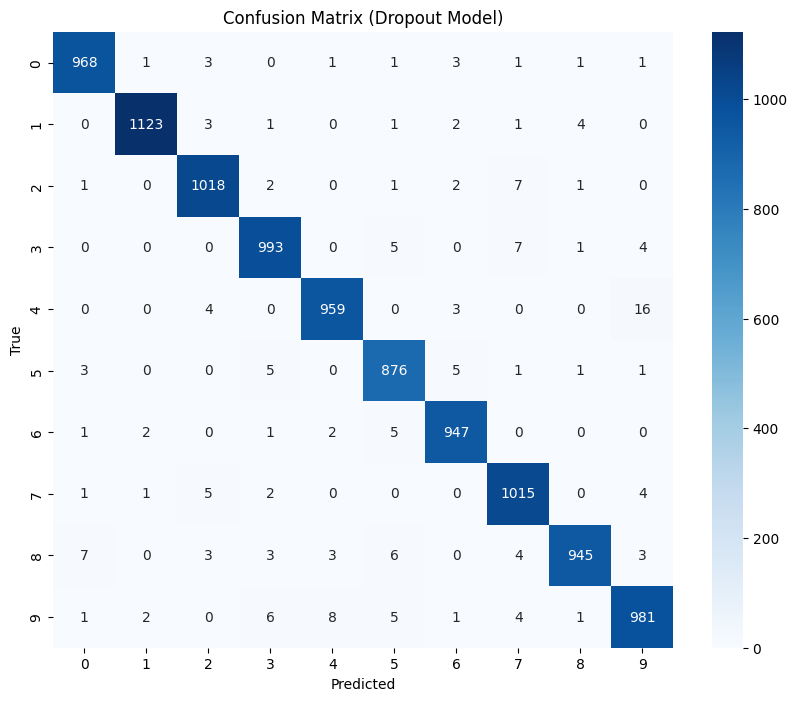

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Ensure test_loader is available
try:
    _ = test_loader
except NameError:
    from torchvision import datasets, transforms
    from torch.utils.data import DataLoader
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

def get_preds(model, loader):
    model.eval()
    ps, ls = [], []
    with torch.no_grad():
        for d, t in loader:
            d, t = d.to(device), t.to(device)
            ps.extend(model(d).argmax(1).cpu().numpy())
            ls.extend(t.cpu().numpy())
    return np.array(ps), np.array(ls)

ps, ls = get_preds(model_with_dropout, test_loader)
cm = confusion_matrix(ls, ps)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Dropout Model)")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [28]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(per_class_accuracy):
    print(f'Accuracy for class {i}: {acc:.4f}')

worst_class_idx = np.argmin(per_class_accuracy)
print(f'\nWorst performing class: {worst_class_idx} with accuracy {per_class_accuracy[worst_class_idx]:.4f}')

Accuracy for class 0: 0.9878
Accuracy for class 1: 0.9894
Accuracy for class 2: 0.9864
Accuracy for class 3: 0.9832
Accuracy for class 4: 0.9766
Accuracy for class 5: 0.9821
Accuracy for class 6: 0.9885
Accuracy for class 7: 0.9874
Accuracy for class 8: 0.9702
Accuracy for class 9: 0.9722

Worst performing class: 8 with accuracy 0.9702


### Bonus: In 5 ảnh bị đoán sai trong lớp tệ nhất

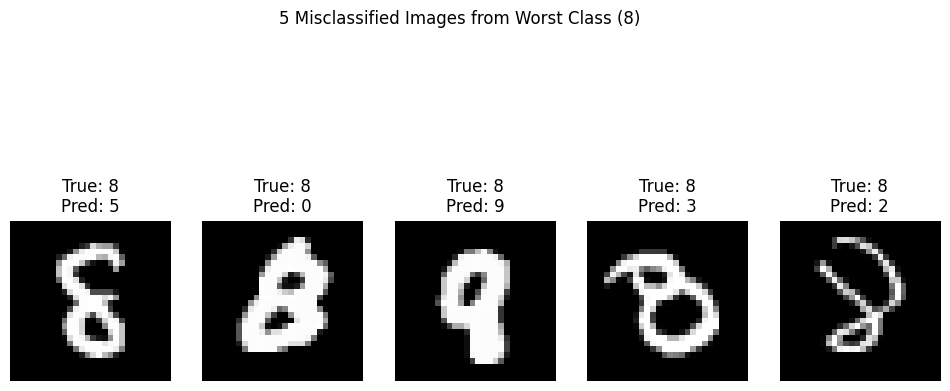

In [29]:
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

model_with_dropout.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model_with_dropout(data)
        preds = output.argmax(dim=1, keepdim=True)

        for i in range(len(target)):
            if target[i].item() == worst_class_idx and preds[i].item() != worst_class_idx:
                misclassified_images.append(data[i].cpu().squeeze().numpy())
                misclassified_labels.append(target[i].item())
                misclassified_preds.append(preds[i].item())

plt.figure(figsize=(12, 6))
for i in range(min(5, len(misclassified_images))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(misclassified_images[i], cmap='gray')
    plt.title(f'True: {misclassified_labels[i]}\nPred: {misclassified_preds[i]}')
    plt.axis('off')
plt.suptitle(f'5 Misclassified Images from Worst Class ({worst_class_idx})')
plt.show()

## Bài 5: Vẽ trọng số của fc1

Trong bài này, chúng ta sẽ lấy trọng số của lớp ẩn đầu tiên (`fc1.weight`) từ mô hình ban đầu (`model_one_hidden`). Mỗi neuron trong lớp này kết nối với tất cả 784 pixel của ảnh đầu vào. Bằng cách reshape các trọng số này về dạng 28x28, chúng ta có thể hình dung được 'mẫu' (template) mà mỗi neuron đang cố gắng tìm kiếm.

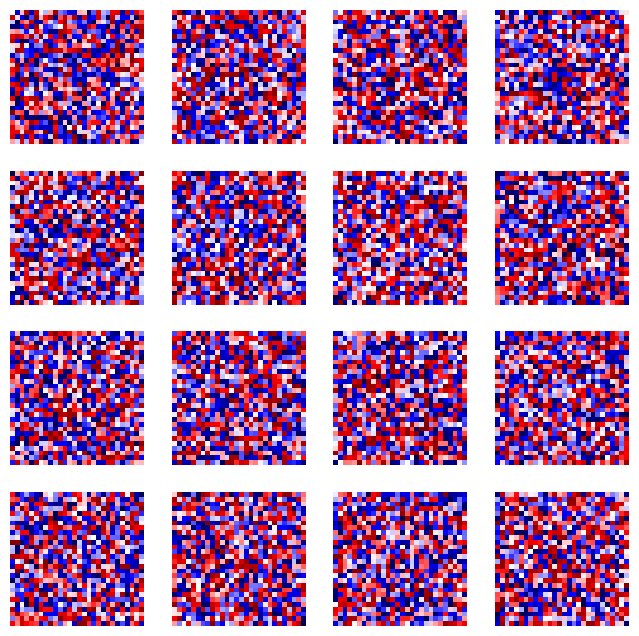

In [24]:
import matplotlib.pyplot as plt

target_model = model_one_hidden if 'model_one_hidden' in globals() else model_with_dropout
weights = target_model.fc1.weight.detach().cpu().view(-1, 28, 28)
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(weights[i], cmap='seismic')
    plt.axis('off')
plt.show()

**Quan sát:** Các ảnh trên đại diện cho các đặc trưng (features) mà các neuron ở lớp đầu tiên học được. Bạn có thể thấy một số neuron tập trung vào các đường cong, nét thẳng hoặc các vùng cụ thể trong khung hình 28x28. Đây chính là cách mạng nơ-ron 'nhìn' thấy các con số.